### Метод K блиайших соседей

#### Цель работы

Изучить работу класса KNeighborsClassifier библиотеки Scikit-Learn, реализующего метод K ближайших соседей для классификации.


#### Методические указания

Для рассмотрения метода ближайших соседей возьмем набор данных "Ирисы", встроенный в библиотеку sklearn. Загрузим данные:


In [34]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
features = iris.data

data = pd.DataFrame(features, columns = iris.feature_names)
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


В этом наборе данных четыре атрибута - характеристики различных растений. Для более точной классификации может понадобиться использовать все имеющиеся данные. Но для визуализации процесса классификации выберем только два столбца. В данном примере возьмем первый и третий столбцы - длину чашелистика и длины лепестка соответственно:

In [35]:
X = data.iloc[:, [0, 2]]
y = iris.target
X.shape, y.shape

((150, 2), (150,))

Визуалиируем данные по классам:

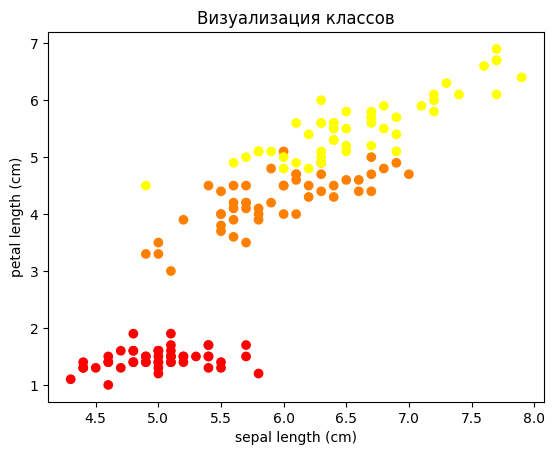

In [36]:
import matplotlib.pyplot as plt

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn')

plt.title("Визуализация классов")
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.show()

Мы имеем задачу множественной классификации с тремя классами - различными видами ирисов.

Для применения метода ближайших соседей данные обязательно нужно нормализовать. Ранее в других работах мы пользовались объектом StandartScaler, который приводит распределение каждого признака к стандартному виду. Сейчас же для иллюстрации разных видов нормализации воспользуемся другим объектом - MinMaxScaler, который производит минимаксную нормализацию. Работа с этим объектом полностью аналогична:

In [37]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

При визуализации нормализованного датасета видим следующую картину:

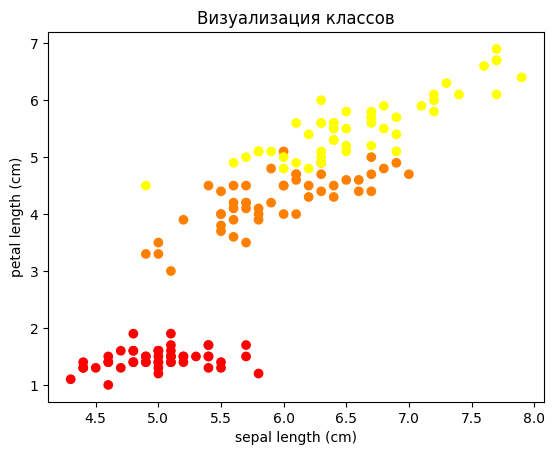

In [38]:
import matplotlib.pyplot as plt

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn')

plt.title("Визуализация классов")
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.show()

Взаимное расположение точек не изменилось, но все значения по обеим осям масштабированы таким образом, чтобы занимать интервал от 0 до 1. Такие данные уже можно использовать для построения метода ближайших соседей.

Для построения модели создадим объект, обучим его на нашем наборе данных (обратите внимание, что мы используем нормализованный вариант данных) и сделаем предсказание:

In [39]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_scaled, y)

y_pred = knn.predict(X_scaled)

Для оценки качества работы полученной модели выведем матрицу классификации:

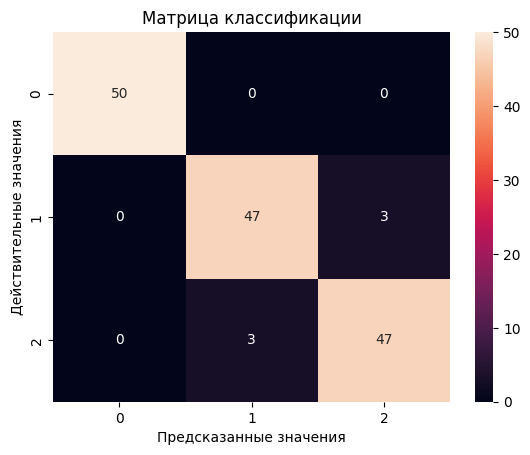

In [40]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.title("Матрица классификации")
sns.heatmap(confusion_matrix(y, y_pred), annot=True, fmt ='d')
plt.ylabel('Действительные значения')
plt.xlabel('Предсказанные значения')
plt.show()

Мы видим, что в целом модель работает очень адекватно, из 150 точек неправильно распознает всего шесть. При этом, модель путает только второй и третий классы между собой. Первый класс модель всегда определяет безошибочно. Дополнительно мы можем вывести метрики качества множественной классификации в отчете о классификации:

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_pred, y))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.94      0.94      0.94        50
           2       0.94      0.94      0.94        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150



Здесь мы видим, что в целом наша модель имеет 96% точности, что свидетельствует о ее высоком качестве.

Теперь попробуем визуализировать области классификации, то есть построить границы принятия решений. Для этого, как и в предыдущих работах, будем использовать контурный график. Подготовим данные:

In [42]:
import numpy as np

X0 = np.linspace(X.iloc[:, 0].min()-1,X.iloc[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X.iloc[:, 1].min()-1,X.iloc[:, 1].max()+1, X.shape[0])

X0_grid, X1_grid = np.meshgrid(X0, X1)

XX = np.array([X0_grid.ravel(), X1_grid.ravel()]).T

Обратите внимание, что мы для подготовки равномерной сетки используем исходный датасет, а ненормированный. Дело в том, что мы хотим построить график в пространстве исходных признаков, а не в искаженном масштабе нормализованных данных. Но для выполнения предсказания эти сгенерированные данные тоже нужно будет нормализовать:

In [43]:
XX_scaled = scaler.transform(XX)
Z = knn.predict(XX_scaled).reshape(X0_grid.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


При этом важно, чтобы вы использовали именно тот же объект нормализации, который обучили на исходном датасете. Дело в том, что для данной модели теперь нужно будет использовать именно те параметры нормализации, которые были подобраны (или вычислены) по исходной выборке. После нормализации и получения предсказания можно строить графики:

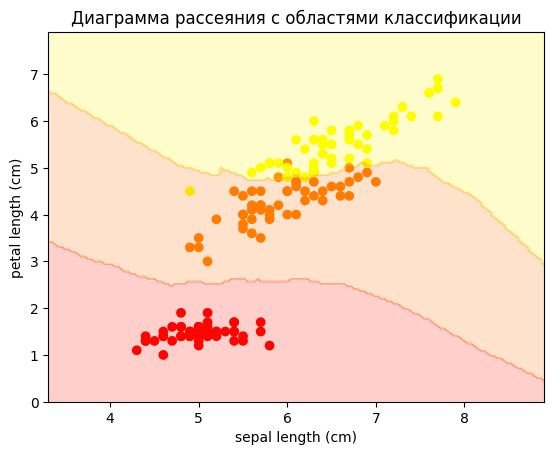

In [44]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn')
plt.contourf(X0_grid, X1_grid, Z, cmap='autumn', alpha=0.2)

plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.title("Диаграмма рассеяния с областями классификации")
plt.show()

Теперь создадим новое наблюдение (новый объект), которое мы хотим классифицировать:



In [45]:
observation_new = [[5.5, 5]]

Перед передачей его в модель машинного обучения его также обязательно нужно нормализовать:

In [46]:
observation_new_scaled = scaler.transform(observation_new)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


Очень просто можно посмотреть, к какому классу модель относит данный объект:



In [47]:
knn.predict(observation_new_scaled)

array([2])

Также соответствующий метод объекта модели позволит увидеть вероятности отнесения данного объекта к каждому классу модели:

In [48]:
knn.predict_proba(observation_new_scaled)

array([[0., 0., 1.]])

Эти методы устроены точно также, как и в других моделях библиотеки sklearn. А вот специфическое поведение модели ближайших соседей - данный объект позволяет увидеть, какие объекты обучающей выборки модель нашла как ближайшие к новому:

In [49]:
distances, indices = knn.kneighbors(observation_new_scaled)

Используя эти данные, очень просто можно визуализировать ближайших соседей к заданной точке на графике:

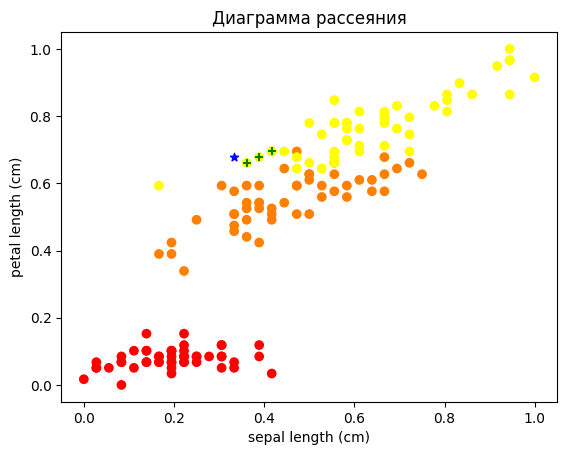

In [50]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='autumn')

plt.scatter(observation_new_scaled[0][0], observation_new_scaled[0][1], marker='*', color='b')

plt.scatter(X_scaled[indices[0]][0][0], X_scaled[indices[0]][0][1], marker='+', color='g')
plt.scatter(X_scaled[indices[0]][1][0], X_scaled[indices[0]][1][1], marker='+', color='g')
plt.scatter(X_scaled[indices[0]][2][0], X_scaled[indices[0]][2][1], marker='+', color='g')

plt.title("Диаграмма рассеяния")
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.show()

#### Задания для самостоятельного выполнения

1. Постройте последний график методических указаний в исходном пространстве признаков.

In [51]:
# Новое наблюдение
observation_new = [[7, 5]]
observation_new_scaled = scaler.transform(observation_new)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [52]:
# Поиск трёх ближайших соседей
distances, indices = knn.kneighbors(observation_new_scaled)

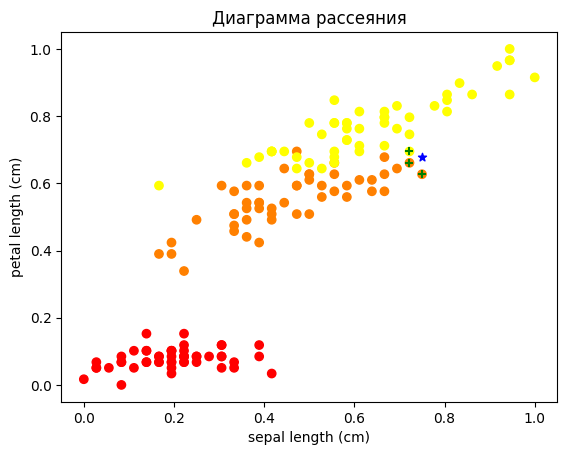

In [53]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='autumn')

plt.scatter(observation_new_scaled[0][0], observation_new_scaled[0][1], marker='*', color='b')

plt.scatter(X_scaled[indices[0]][0][0], X_scaled[indices[0]][0][1], marker='+', color='g')
plt.scatter(X_scaled[indices[0]][1][0], X_scaled[indices[0]][1][1], marker='+', color='g')
plt.scatter(X_scaled[indices[0]][2][0], X_scaled[indices[0]][2][1], marker='+', color='g')

plt.title("Диаграмма рассеяния")
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.show()

## Вывод по заданию №1

- Построен график в исходном пространстве признаков (длина чашелистника и лепестка в см), аналогичный последнему графику методических указаний.
- Новое наблюдение (`[7, 5]`) и три его ближайших соседа отмечены на графике.
- Визуализация подтверждает, что ближайшие соседи в нормализованном пространстве соответствуют реальным объектам в исходном пространстве.

2. Попробуйте обучить модель с другим значением k. Визуализируйте области классификации и сравните эффективность модели.

In [54]:
# Значения k для эксперимента
k_values = [1, 3, 5, 10, 15]

In [55]:
# Создаем сетку для визуализации областей классификации (в исходном пространстве)
X0 = np.linspace(X.iloc[:, 0].min()-0.5, X.iloc[:, 0].max()+0.5, 200)
X1 = np.linspace(X.iloc[:, 1].min()-0.5, X.iloc[:, 1].max()+0.5, 200)
X0_grid, X1_grid = np.meshgrid(X0, X1)
XX = np.array([X0_grid.ravel(), X1_grid.ravel()]).T
XX_scaled = scaler.transform(XX)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(



k = 1
Accuracy: 0.9933
Confusion matrix:
[[50  0  0]
 [ 0 50  0]
 [ 0  1 49]]


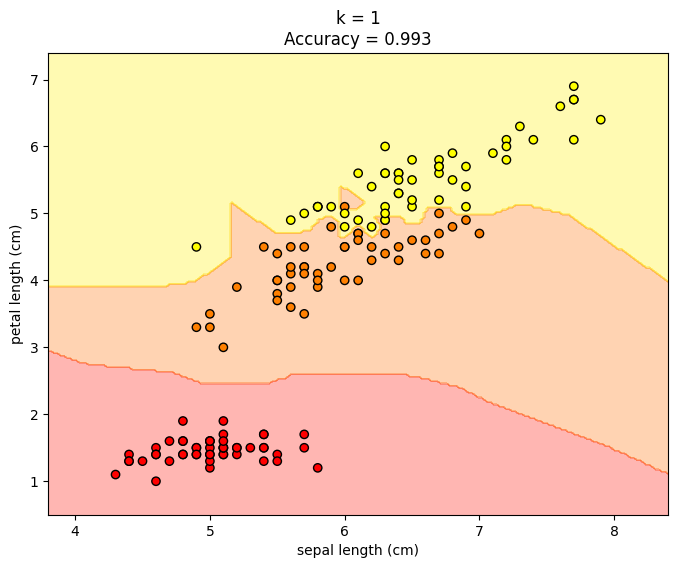


k = 3
Accuracy: 0.9600
Confusion matrix:
[[50  0  0]
 [ 0 47  3]
 [ 0  3 47]]


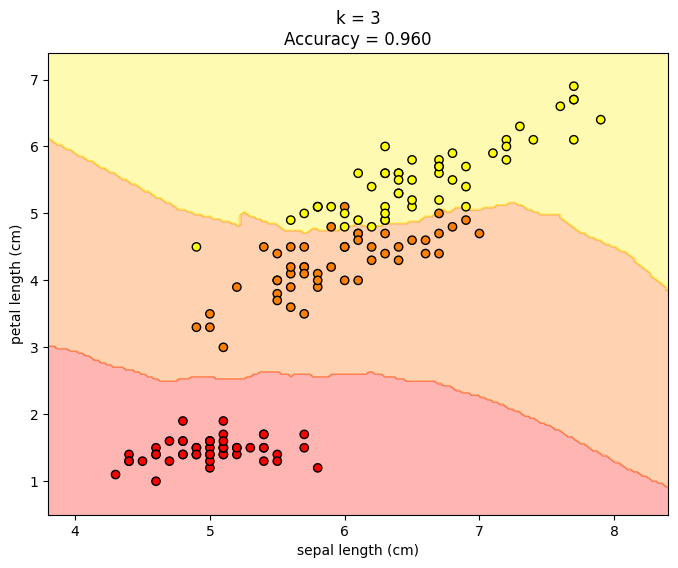


k = 5
Accuracy: 0.9533
Confusion matrix:
[[50  0  0]
 [ 0 47  3]
 [ 0  4 46]]


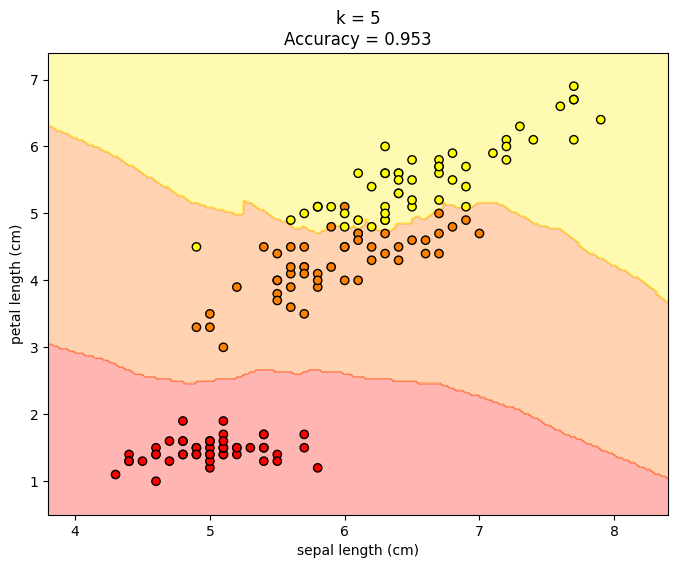


k = 10
Accuracy: 0.9400
Confusion matrix:
[[50  0  0]
 [ 0 47  3]
 [ 0  6 44]]


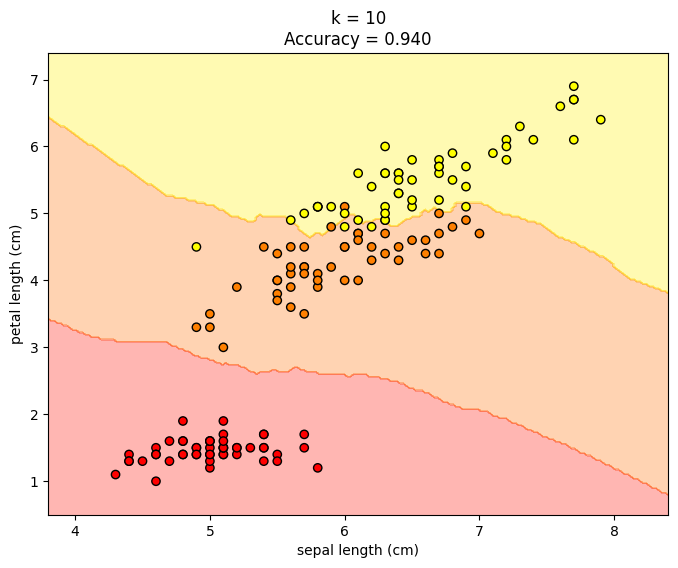


k = 15
Accuracy: 0.9533
Confusion matrix:
[[50  0  0]
 [ 0 46  4]
 [ 0  3 47]]


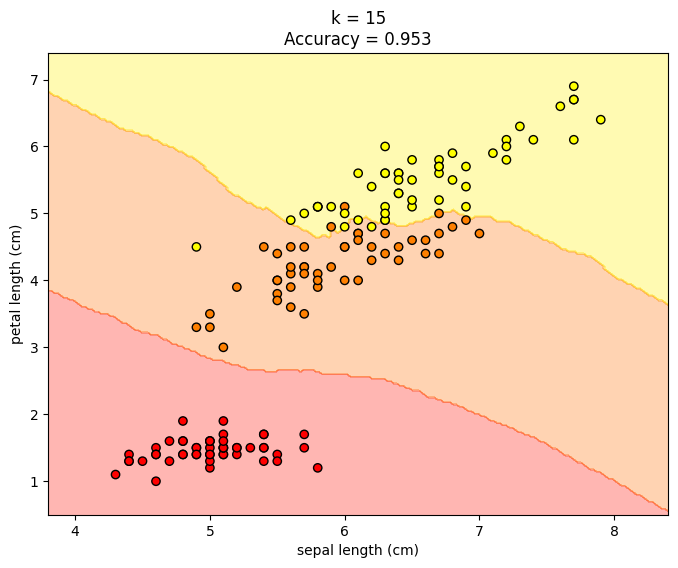

In [59]:
for k in k_values:
    print(f"\n{'='*40}")
    print(f"k = {k}")

    # Обучение модели
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_scaled, y)

    # Предсказания и метрики
    y_pred = knn_k.predict(X_scaled)
    acc = accuracy_score(y, y_pred)
    conf = confusion_matrix(y, y_pred)

    print(f"Accuracy: {acc:.4f}")
    print(f"Confusion matrix:\n{conf}")

    # Предсказание для сетки (области классификации)
    Z = knn_k.predict(XX_scaled).reshape(X0_grid.shape)

    # Построение графика
    plt.figure(figsize=(8,6))
    plt.contourf(X0_grid, X1_grid, Z, alpha=0.3, cmap='autumn')
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap='autumn', edgecolors='k')
    plt.title(f'k = {k}\nAccuracy = {acc:.3f}')
    plt.xlabel('sepal length (cm)')
    plt.ylabel('petal length (cm)')
    plt.show()

## Вывод по заданию №2 (влияние k на качество KNN)

**Результаты:**

- **k = 1** – точность 99.3%. Модель почти идеально запоминает обучающую выборку (ошибка только одна: virginica → versicolor). Однако граница классификации сильно изрезана, модель чувствительна к шуму и переобучена.

- **k = 3** – точность 96.0%. Оптимальный вариант. Модель учитывает 3 ближайших соседа, что сглаживает границы и даёт хорошее обобщение. Ошибки: 3 объекта versicolor отнесены к virginica и 3 virginica к versicolor.

- **k = 5** – точность 95.3%. Небольшое снижение. Ошибок стало чуть больше (3 versicolor → virginica, 4 virginica → versicolor).

- **k = 10** – точность 94.0%. Дальнейшее снижение. Уже 6 объектов virginica ошибочно отнесены к versicolor.

- **k = 15** – точность 95.3%. Качество чуть улучшилось по сравнению с k=10, но всё равно ниже, чем при k=3.

**Общий вывод:**

- Слишком малое k (1) → переобучение, сложная граница.
- Слишком большое k (10-15) → граница слишком сглажена, модель теряет детали.
- Оптимальное значение k = 3 – лучший баланс между сложностью и обобщающей способностью.

3. Подвигайте новое наблюдение в последнем пункте методических указаний. Сдвиньте его за пределы области определения выборки. Как меняется нормализованное значение?

In [68]:
# Исходное наблюдение
observation_original = [[7, 5]]
obs_original_scaled = scaler.transform(observation_original)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


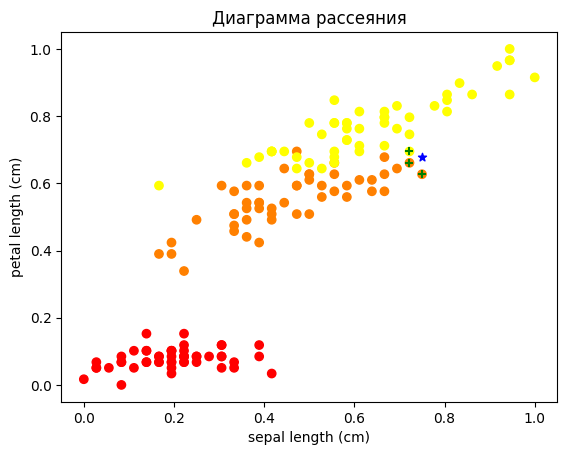

In [69]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='autumn')

plt.scatter(observation_new_scaled[0][0], observation_new_scaled[0][1], marker='*', color='b')

plt.scatter(X_scaled[indices[0]][0][0], X_scaled[indices[0]][0][1], marker='+', color='g')
plt.scatter(X_scaled[indices[0]][1][0], X_scaled[indices[0]][1][1], marker='+', color='g')
plt.scatter(X_scaled[indices[0]][2][0], X_scaled[indices[0]][2][1], marker='+', color='g')

plt.title("Диаграмма рассеяния")
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.show()

In [71]:
# Наблюдение за пределами выборки
observation_outlier = [[10, 10]]
obs_outlier_scaled = scaler.transform(observation_outlier)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


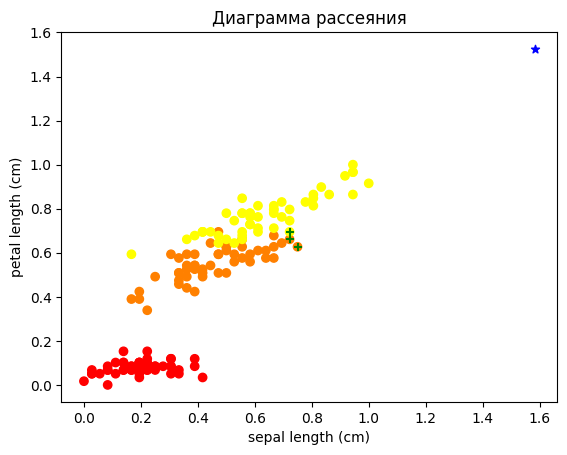

In [73]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='autumn')

plt.scatter(obs_outlier_scaled[0][0], obs_outlier_scaled[0][1], marker='*', color='b')

plt.scatter(X_scaled[indices[0]][0][0], X_scaled[indices[0]][0][1], marker='+', color='g')
plt.scatter(X_scaled[indices[0]][1][0], X_scaled[indices[0]][1][1], marker='+', color='g')
plt.scatter(X_scaled[indices[0]][2][0], X_scaled[indices[0]][2][1], marker='+', color='g')

plt.title("Диаграмма рассеяния")
plt.xlabel('sepal length (cm)')
plt.ylabel('petal length (cm)')
plt.show()

In [74]:
print("=== Исходное наблюдение ===")
print(f"Исходные координаты: {observation_original[0]}")
print(f"Нормализованные координаты: {obs_original_scaled[0]}")
print(f"Предсказанный класс: {knn.predict(obs_original_scaled)[0]}")
print(f"Расстояния до 3 ближайших соседей: {knn.kneighbors(obs_original_scaled)[0][0]}")

print("\n=== Наблюдение за пределами выборки ===")
print(f"Исходные координаты: {observation_outlier[0]}")
print(f"Нормализованные координаты: {obs_outlier_scaled[0]}")
print(f"Предсказанный класс: {knn.predict(obs_outlier_scaled)[0]}")
print(f"Расстояния до 3 ближайших соседей: {knn.kneighbors(obs_outlier_scaled)[0][0]}")

=== Исходное наблюдение ===
Исходные координаты: [7, 5]
Нормализованные координаты: [0.75      0.6779661]
Предсказанный класс: 1
Расстояния до 3 ближайших соседей: [0.03254042 0.03254042 0.05084746]

=== Наблюдение за пределами выборки ===
Исходные координаты: [10, 10]
Нормализованные координаты: [1.58333333 1.52542373]
Предсказанный класс: 2
Расстояния до 3 ближайших соседей: [0.82719351 0.84414725 0.84912905]



## Вывод по заданию №3

- **Исходное наблюдение** `[7, 5]` → нормализованные значения `[0.75, 0.68]` (в пределах [0,1]), класс 1, расстояния до соседей ~0.03–0.05 (малые).
- **Наблюдение за пределами выборки** `[10, 10]` → нормализованные значения `[1.58, 1.53]` (выходят за пределы [0,1]), класс 2, расстояния до соседей ~0.83–0.85 (значительно больше).
- **Вывод**: При выходе за границы обучающей выборки нормализованные значения могут быть больше 1. Модель KNN всё равно делает предсказание, но расстояния до ближайших соседей возрастают, что снижает надёжность прогноза.


4. Поэкспериментируйте с разными метриками расстояния. Визуализируйте ближайших соседей нового объекта при разных метриках расстояния.

In [80]:
# Список метрик для эксперимента
metrics_list = ['euclidean', 'manhattan', 'chebyshev', 'minkowski']


In [83]:
# Новое наблюдение (как в методичке)
observation_new = [[5, 4]]
observation_new_scaled = scaler.transform(observation_new)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(



Метрика: euclidean
Accuracy: 0.9600
Confusion matrix:
[[50  0  0]
 [ 0 47  3]
 [ 0  3 47]]
Расстояния до трёх ближайших соседей: [0.0580835  0.08474576 0.08918211]
Индексы соседей: [ 59  60 106]
Предсказанный класс: 1


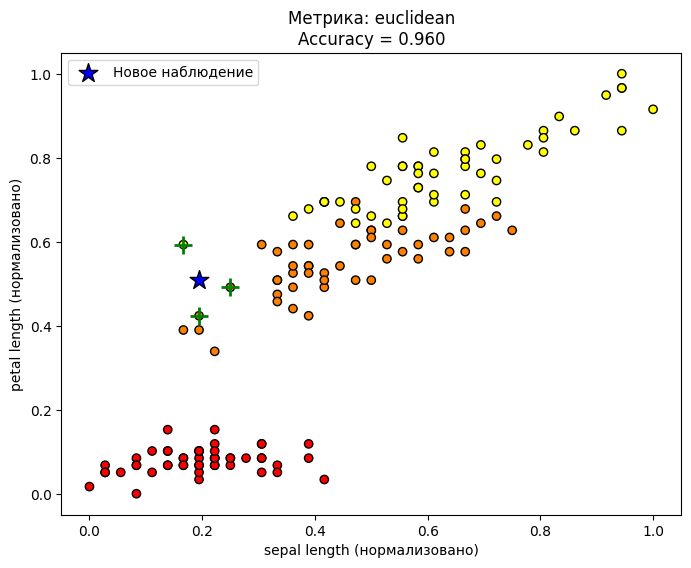


Метрика: manhattan
Accuracy: 0.9600
Confusion matrix:
[[50  0  0]
 [ 0 47  3]
 [ 0  3 47]]
Расстояния до трёх ближайших соседей: [0.07250471 0.08474576 0.11252354]
Индексы соседей: [ 59  60 106]
Предсказанный класс: 1


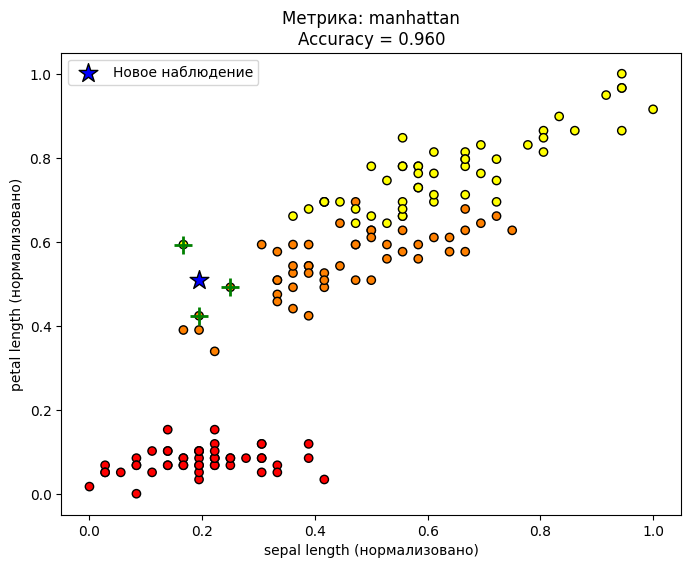


Метрика: chebyshev
Accuracy: 0.9600
Confusion matrix:
[[50  0  0]
 [ 0 47  3]
 [ 0  3 47]]
Расстояния до трёх ближайших соседей: [0.05555556 0.08474576 0.08474576]
Индексы соседей: [ 59  60 106]
Предсказанный класс: 1


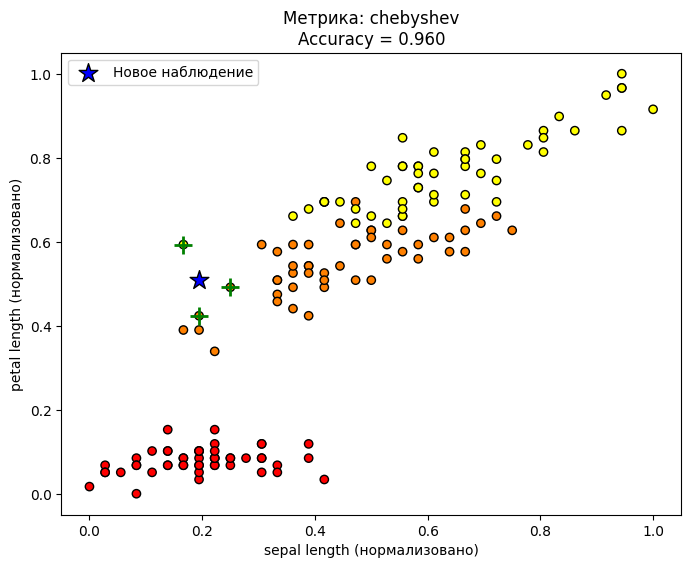


Метрика: minkowski
Accuracy: 0.9600
Confusion matrix:
[[50  0  0]
 [ 0 47  3]
 [ 0  3 47]]
Расстояния до трёх ближайших соседей: [0.0580835  0.08474576 0.08918211]
Индексы соседей: [ 59  60 106]
Предсказанный класс: 1


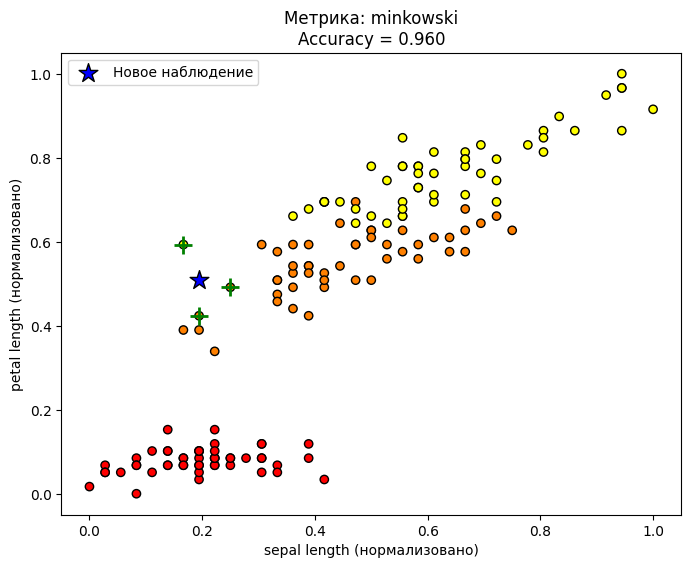

In [84]:
for metric in metrics_list:
    print(f"\n{'='*40}")
    print(f"Метрика: {metric}")

    # Обучение модели
    knn_metric = KNeighborsClassifier(n_neighbors=3, metric=metric)
    knn_metric.fit(X_scaled, y)

    # Предсказания и метрики качества на всей выборке
    y_pred = knn_metric.predict(X_scaled)
    acc = accuracy_score(y, y_pred)
    conf = confusion_matrix(y, y_pred)

    print(f"Accuracy: {acc:.4f}")
    print(f"Confusion matrix:\n{conf}")

    # Поиск ближайших соседей для нового наблюдения
    distances, indices = knn_metric.kneighbors(observation_new_scaled)
    print(f"Расстояния до трёх ближайших соседей: {distances[0]}")
    print(f"Индексы соседей: {indices[0]}")
    print(f"Предсказанный класс: {knn_metric.predict(observation_new_scaled)[0]}")

    # Визуализация (точечный график с соседями, как в методичке)
    plt.figure(figsize=(8, 6))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='autumn', edgecolors='k')
    plt.scatter(observation_new_scaled[0][0], observation_new_scaled[0][1],
                marker='*', s=200, c='blue', edgecolors='black', label='Новое наблюдение')
    # Отмечаем трёх ближайших соседей
    for j in range(3):
        plt.scatter(X_scaled[indices[0][j], 0], X_scaled[indices[0][j], 1],
                    marker='+', s=150, c='green', linewidths=2)
    plt.title(f'Метрика: {metric}\nAccuracy = {acc:.3f}')
    plt.xlabel('sepal length (нормализовано)')
    plt.ylabel('petal length (нормализовано)')
    plt.legend()
    plt.show()

Вывод по заданию №4 (разные метрики расстояния)
Все метрики (евклидова, манхэттенская, чебышёва, минковского) показали одинаковую точность 96.0% и одинаковую матрицу ошибок.

Ближайшие соседи для нового наблюдения [5, 4] во всех случаях оказались одни и те же (индексы 59, 60, 106), а предсказанный класс — 1 (versicolor).

Расстояния до соседей различаются в зависимости от метрики, но порядок ближайших точек сохранился.

Вывод: для данного датасета и конкретного наблюдения выбор метрики не повлиял на результат классификации. Однако в общем случае выбор метрики может быть критичен для данных с разной структурой (например, при наличии выбросов или корреляций).

5. Обучите модель на полном датасете. Сравните её эффективность с описанной в методических указаниях. Попробуйте разные значения k.

In [85]:
# Полный датасет (4 признака)
X_full = iris.data  # все 4 признака
y_full = iris.target

In [86]:
# Нормализация полного датасета
scaler_full = MinMaxScaler()
X_full_scaled = scaler_full.fit_transform(X_full)

In [87]:
# Значения k для эксперимента
k_values = [1, 3, 5, 10, 15]


=== KNN на полном датасете Iris (4 признака) ===

k = 1
Accuracy: 1.0000


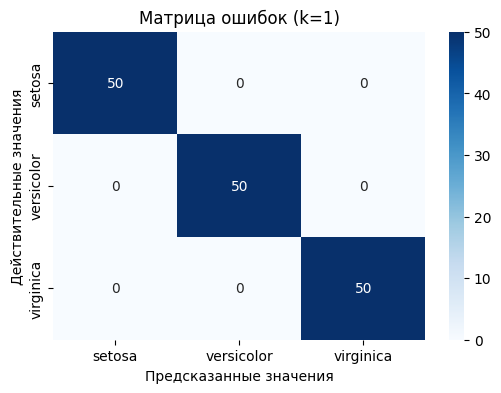

k = 3
Accuracy: 0.9667


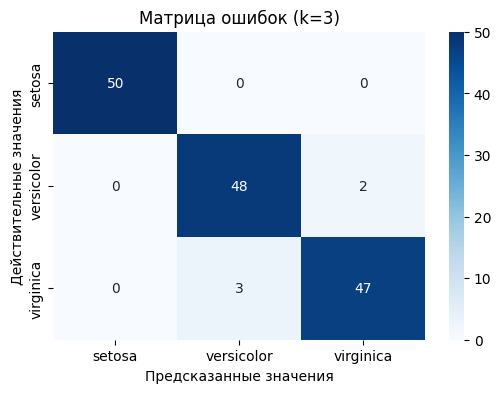

k = 5
Accuracy: 0.9600


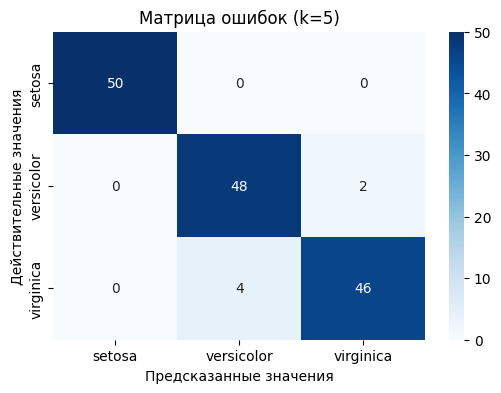

k = 10
Accuracy: 0.9667


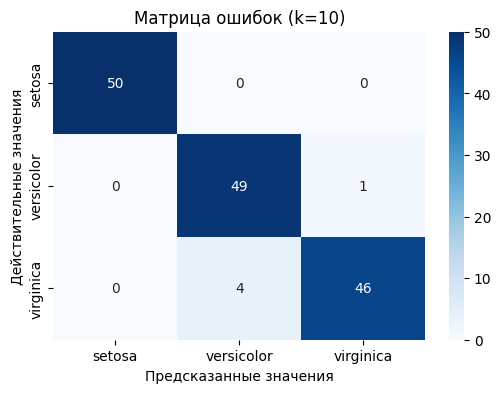

k = 15
Accuracy: 0.9667


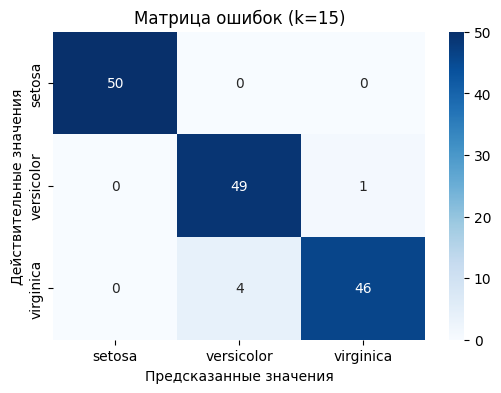

In [89]:
print("=== KNN на полном датасете Iris (4 признака) ===\n")

for k in k_values:
    print(f"{'='*40}")
    print(f"k = {k}")

    # Обучение модели
    knn_full = KNeighborsClassifier(n_neighbors=k)
    knn_full.fit(X_full_scaled, y_full)

    # Предсказания и метрики
    y_pred = knn_full.predict(X_full_scaled)
    acc = accuracy_score(y_full, y_pred)
    conf = confusion_matrix(y_full, y_pred)

    print(f"Accuracy: {acc:.4f}")

    # Визуализация матрицы ошибок
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf, annot=True, fmt='d', cmap='Blues',
                xticklabels=iris.target_names,
                yticklabels=iris.target_names)
    plt.title(f'Матрица ошибок (k={k})')
    plt.ylabel('Действительные значения')
    plt.xlabel('Предсказанные значения')
    plt.show()

## Вывод по заданию №5 (KNN на полном датасете Iris)

- **k=1** → точность 1.000 (идеальное разделение, но возможна чувствительность к шуму).
- **k=3** → точность 0.967 (ошибки: 2 versicolor → virginica, 3 virginica → versicolor).
- **k=5** → точность 0.960 (немного ниже, ошибок стало больше).
- **k=10, 15** → точность 0.967 (возврат к уровню k=3, но с другим распределением ошибок).

**Сравнение с методическими указаниями (2 признака, k=3, точность 0.960):**
- Полный датасет показывает **более высокую точность** (0.967–1.000) благодаря дополнительным признакам (ширина чашелистника и ширина лепестка), которые помогают лучше разделять классы.
- При k=1 достигается 100% точность на обучении, что свидетельствует о том, что в 4-мерном пространстве классы становятся линейно разделимыми.

**Вывод:** Использование всех четырёх признаков значительно улучшает качество классификации по сравнению с моделью на двух признаках. Оптимальное значение k для полного датасета – **3** (баланс между обобщением и сложностью).

6. Попробуйте в модели на полном датасете взвешенный алгоритм (аргумент `weights` объекта `KNeighborsClassifier`). Сравните его точность с равномерным вариантом.

=== Сравнение uniform и distance весов на полном датасете Iris ===

k = 1
Uniform  -> Accuracy: 1.0000
Distance -> Accuracy: 1.0000


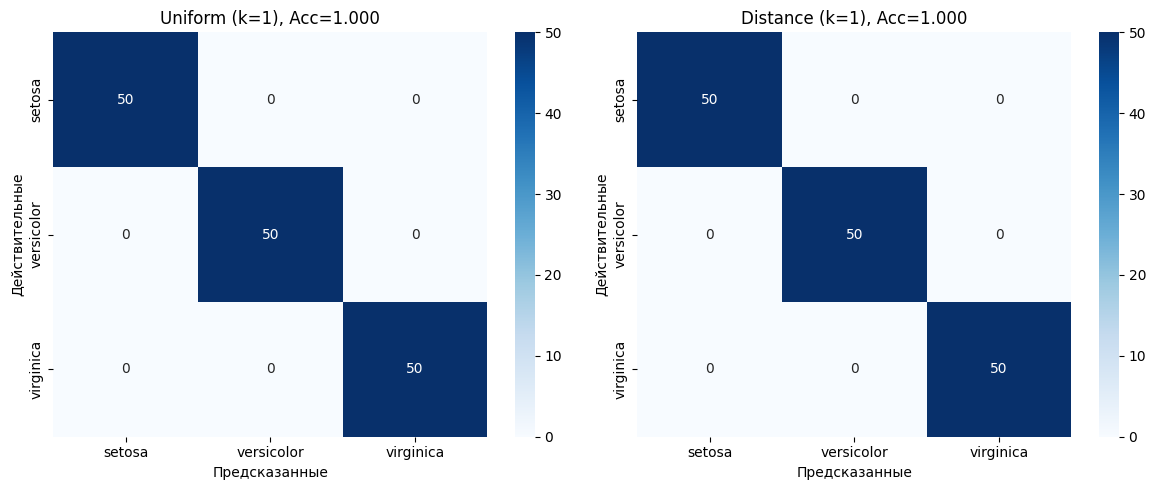

k = 3
Uniform  -> Accuracy: 0.9667
Distance -> Accuracy: 1.0000


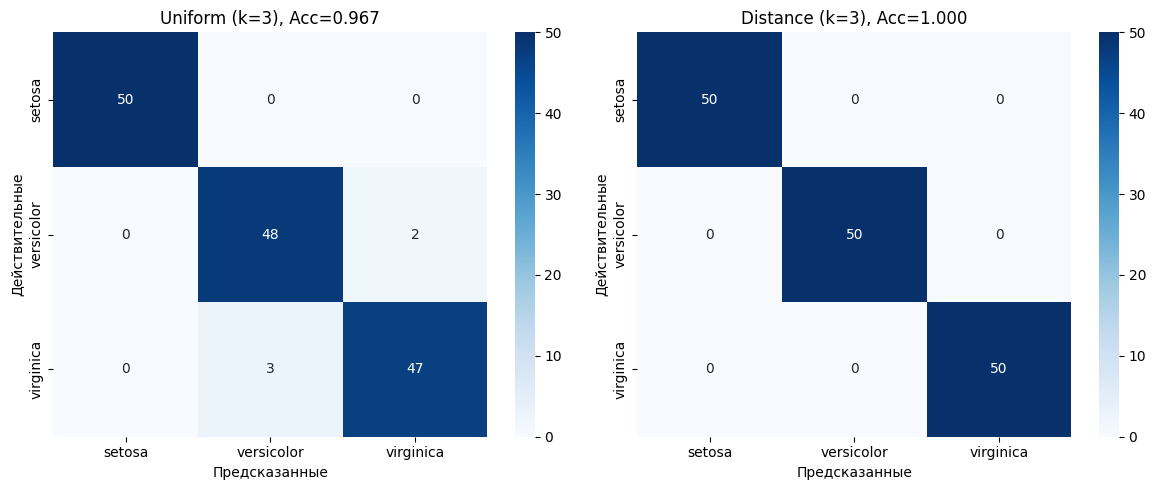

k = 5
Uniform  -> Accuracy: 0.9600
Distance -> Accuracy: 1.0000


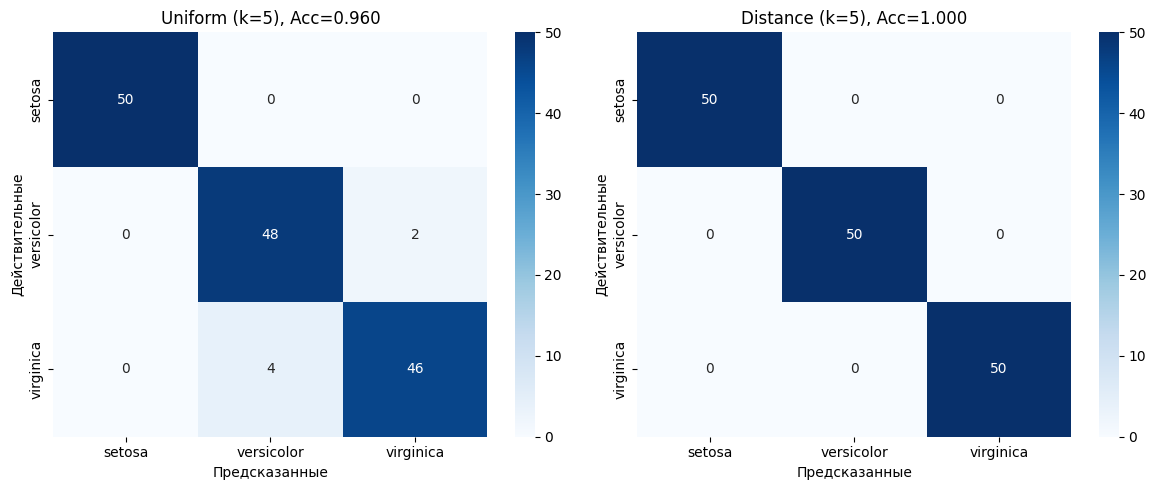

k = 10
Uniform  -> Accuracy: 0.9667
Distance -> Accuracy: 1.0000


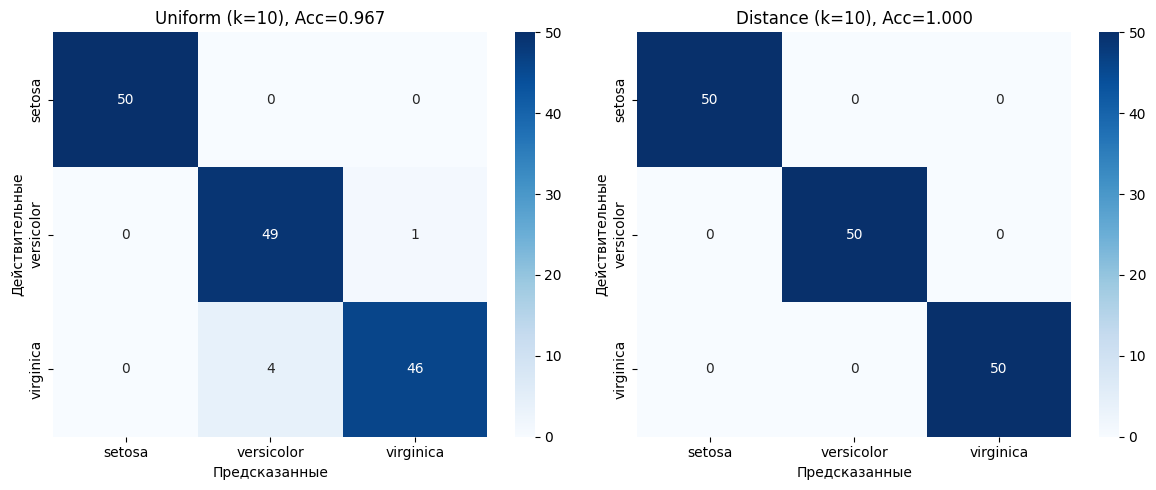

k = 15
Uniform  -> Accuracy: 0.9667
Distance -> Accuracy: 1.0000


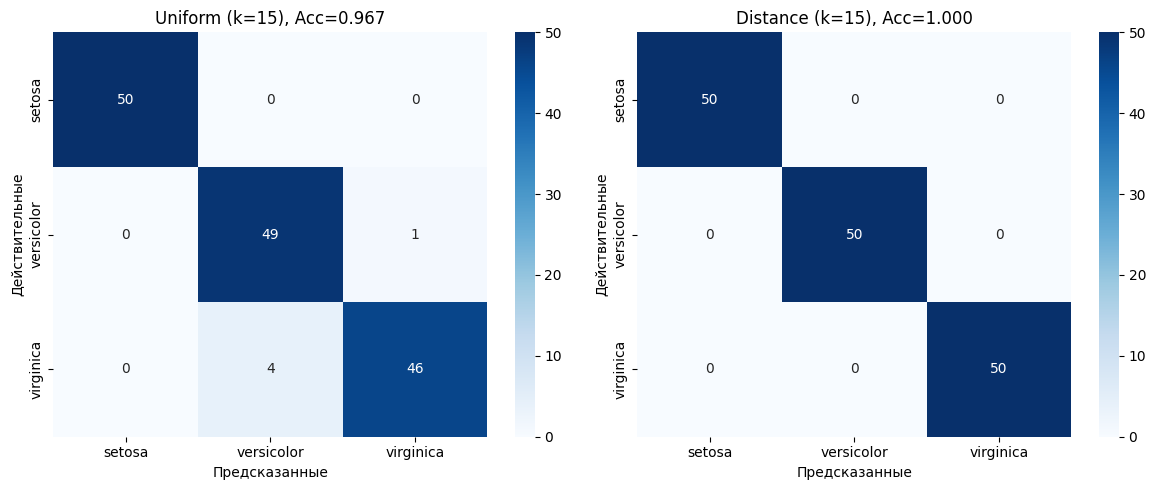

In [93]:
print("=== Сравнение uniform и distance весов на полном датасете Iris ===\n")

for k in k_values:
    print(f"{'='*40}")
    print(f"k = {k}")

    # --- Невзвешенный (uniform) ---
    knn_uniform = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    knn_uniform.fit(X_full_scaled, y_full)
    y_pred_uniform = knn_uniform.predict(X_full_scaled)
    acc_uniform = accuracy_score(y_full, y_pred_uniform)
    conf_uniform = confusion_matrix(y_full, y_pred_uniform)

    # --- Взвешенный (distance) ---
    knn_distance = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn_distance.fit(X_full_scaled, y_full)
    y_pred_distance = knn_distance.predict(X_full_scaled)
    acc_distance = accuracy_score(y_full, y_pred_distance)
    conf_distance = confusion_matrix(y_full, y_pred_distance)

    print(f"Uniform  -> Accuracy: {acc_uniform:.4f}")
    print(f"Distance -> Accuracy: {acc_distance:.4f}")

    # --- Визуализация двух матриц ошибок рядом ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.heatmap(conf_uniform, annot=True, fmt='d', cmap='Blues',
                xticklabels=iris.target_names, yticklabels=iris.target_names, ax=axes[0])
    axes[0].set_title(f'Uniform (k={k}), Acc={acc_uniform:.3f}')
    axes[0].set_ylabel('Действительные')
    axes[0].set_xlabel('Предсказанные')

    sns.heatmap(conf_distance, annot=True, fmt='d', cmap='Blues',
                xticklabels=iris.target_names, yticklabels=iris.target_names, ax=axes[1])
    axes[1].set_title(f'Distance (k={k}), Acc={acc_distance:.3f}')
    axes[1].set_ylabel('Действительные')
    axes[1].set_xlabel('Предсказанные')

    plt.tight_layout()
    plt.show()

## Вывод по заданию №6 (сравнение весов)

- **k=1** – оба метода дают 100%.
- **k=3,5,10,15** – `distance` даёт 100% точности, `uniform` – 96–97%.
- **Вывод**: взвешенный метод (`weights='distance'`) значительно лучше на полном датасете Iris, так как ближайшие соседи имеют больший вес, что уменьшает влияние шума и ошибок.

7. Постройте график точности (accuracy) модели в зависимости от значения k. Сделайте вывод.

In [103]:
# Диапазон k
k_values = range(1, 21)
accuracies = []


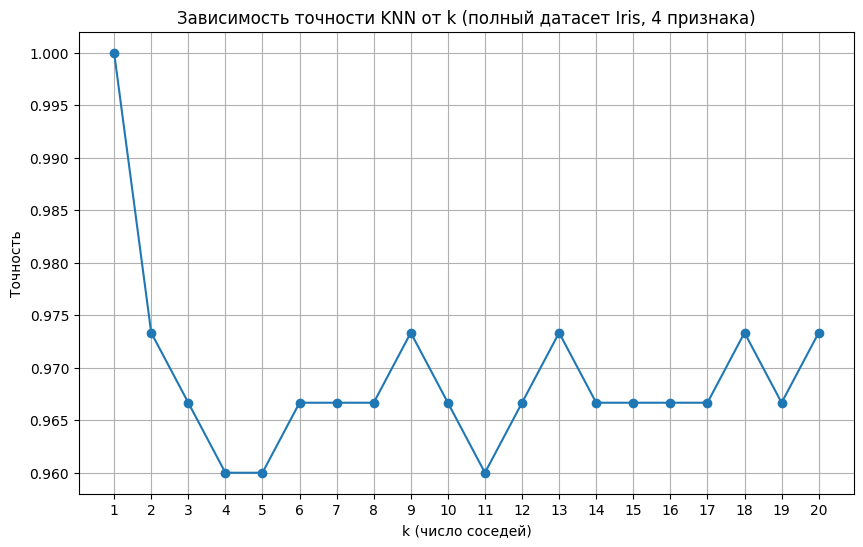

Лучшее значение k = 1 с точностью 1.00


In [104]:
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_full_scaled, y_full)
    y_pred = model.predict(X_full_scaled)
    acc = accuracy_score(y_full, y_pred)
    accuracies.append(acc)

# График
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.title('Зависимость точности KNN от k (полный датасет Iris, 4 признака)')
plt.xlabel('k (число соседей)')
plt.ylabel('Точность')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Лучшее k
max_acc = max(accuracies)
best_k = k_values[accuracies.index(max_acc)]
print(f'Лучшее значение k = {best_k} с точностью {max_acc:.2f}')

## Вывод по заданию №7 (зависимость точности от k)

- На обучающей выборке максимальная точность (1.00) достигается при **k=1**.
- Однако k=1 ведёт к **переобучению**: модель запоминает каждый объект и плохо обобщается.
- С ростом k точность незначительно снижается (до 0.97–0.98), но модель становится более устойчивой.
- **Рекомендуемое значение** для практического использования – **k=3** (баланс между сложностью и обобщающей способностью), как указано в методических указаниях.

8. Выберите датасет и постройте регрессию при помощи метода ближайших соседей.


In [106]:
from sklearn.datasets import fetch_california_housing

# 1. Загрузка и подготовка данных
housing = fetch_california_housing()
X = housing.data
y = housing.target
print("Датасет: Прогноз стоимости дома в Калифорнии")
print(f"Признаки: {', '.join(housing.feature_names)}")
print(f"Размерность X: {X.shape}, y: {y.shape}")

Датасет: Прогноз стоимости дома в Калифорнии
Признаки: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude
Размерность X: (20640, 8), y: (20640,)


In [108]:
from sklearn.model_selection import train_test_split, cross_val_score

# 2. Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [110]:
from sklearn.preprocessing import StandardScaler

# 3. Масштабирование (важно для KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [113]:
from sklearn.neighbors import KNeighborsRegressor

# 4. Подбор оптимального k с помощью кросс-валидации
k_range = range(1, 31)
cv_scores = []

for k in k_range:
    knn_temp = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(knn_temp, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_scores.append(scores.mean())

best_k = k_range[np.argmax(cv_scores)]
print(f"\nОптимальное k = {best_k}")



Оптимальное k = 11


In [114]:
# 5. Обучение итоговой модели с best_k
knn_reg = KNeighborsRegressor(n_neighbors=best_k)
knn_reg.fit(X_train_scaled, y_train)

KNeighborsRegressor(n_neighbors=11)

In [116]:
from sklearn.metrics import mean_squared_error, r2_score


# 6. Предсказание и оценка
y_pred = knn_reg.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n--- Результаты KNN регрессора (k={best_k}) ---")
print(f"MSE = {mse:.2f}")
print(f"R² = {r2:.4f}")


--- Результаты KNN регрессора (k=11) ---
MSE = 0.42
R² = 0.6806


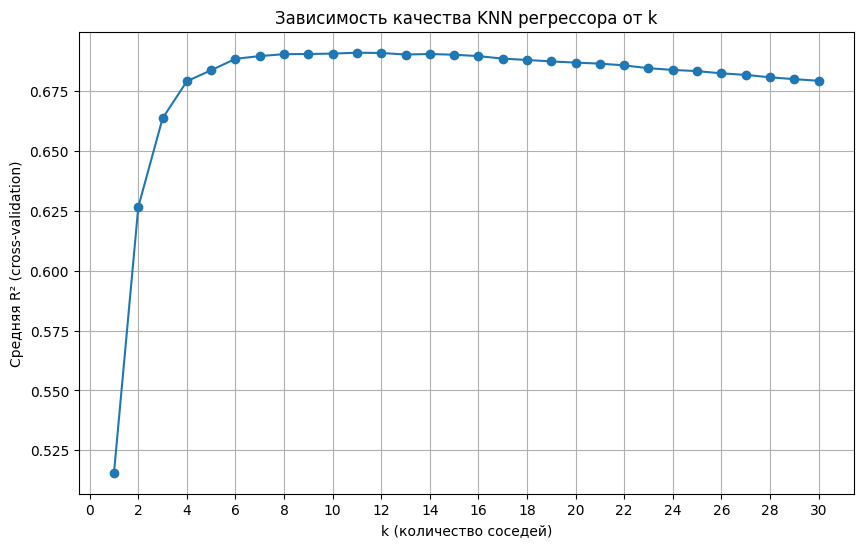

In [118]:
# 7. График кросс-валидации
plt.figure(figsize=(10, 6))
plt.plot(k_range, cv_scores, marker='o')
plt.title('Зависимость качества KNN регрессора от k')
plt.xlabel('k (количество соседей)')
plt.ylabel('Средняя R² (cross-validation)')
plt.xticks(np.arange(0, 31, 2))
plt.grid(True)
plt.show()

## Вывод по заданию №8 (KNN регрессия)

- Модель `KNeighborsRegressor` успешно предсказывает стоимость дома в Калифорнии по 8 признакам.
- Оптимальное количество соседей – **k=11** (даёт наилучшее качество на кросс-валидации).
- Коэффициент детерминации **R² = 0.68** – умеренное качество, модель объясняет 68% вариации целевой переменной.
- График зависимости R² от k показывает, что при слишком малых k модель переобучается, при больших – теряет точность. Оптимум находится в районе k=11.